# Assignment template

## Business Understanding

The goal is to segment drone delivery customer locations into geographic groups and to find frequent combinations of purchased product groups.
Customer clusters can improve routing and hub placement, while association rules can reveal product bundle patterns for marketing or inventory planning.

In [2]:
import time
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.cluster.hierarchy import centroid
from sklearn.cluster import KMeans
from sklearn.cluster import AgglomerativeClustering


## Data understanding

Here we prepare customer dataset. The dataset includes information such as customer locations and unique identification number.
   - "clientid" is the customer unique identification number
   - "x-column" column represents longitude
   - "y-column" column represents latitude

The objective is  group customers into clusters based on their geographical proximity using K-means clustering.

In [3]:
cust_data = pd.read_csv('datasets/drone_cust_locations.csv', sep=';')
cust_data.head()

,clientid,x,y
0,1,622.771572,164.857623
1,2,416.357298,630.193634
2,3,292.735020,567.333231
3,4,737.211288,166.225676
4,5,540.475375,682.912298


In this codeblock we prepare Product-groups dataset. Dataset contains information about what type of products customers have purchased.
   - "ID" is the unique identifier for the transaction
   - "Prod1-Prod20" Binary variables indicating whether at least one product from a particular group was purchased in the transaction. A value of 1 indicates that at least one product from the group was purchased, while a value of 0 indicates that no products from the group were purchased.

The objective is to discover frequent itemsets and association rules using the apriori algorithm

In [4]:
prod_data = pd.read_csv('datasets/drone_prod_groups.csv')
prod_data.head()

,ID,Prod1,Prod2,Prod3,Prod4,Prod5,Prod6,Prod7,Prod8,Prod9,...,Prod11,Prod12,Prod13,Prod14,Prod15,Prod16,Prod17,Prod18,Prod19,Prod20
0,1,0,0,0,0,0,0,0,0,1,...,0,0,0,0,1,0,0,0,0,1
1,2,0,1,0,0,0,0,0,0,1,...,0,0,0,0,1,1,1,1,1,1
2,3,0,0,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,1,1
3,4,1,0,0,1,0,0,0,0,0,...,1,0,0,0,0,0,0,0,1,1
4,5,0,0,0,0,0,0,0,0,1,...,0,0,0,0,1,0,0,0,1,1


## Data preparation

In this codeblock we prepare Customer Location-dataset and formats all columns for better readability.

In [5]:
cust_data_clean = cust_data.rename(columns={'x':'Longitude', 'y':'Latitude', 'clientid':'CustomerId'})
cust_data_clean.head()

,CustomerId,Longitude,Latitude
0,1,622.771572,164.857623
1,2,416.357298,630.193634
2,3,292.735020,567.333231
3,4,737.211288,166.225676
4,5,540.475375,682.912298


## Modeling

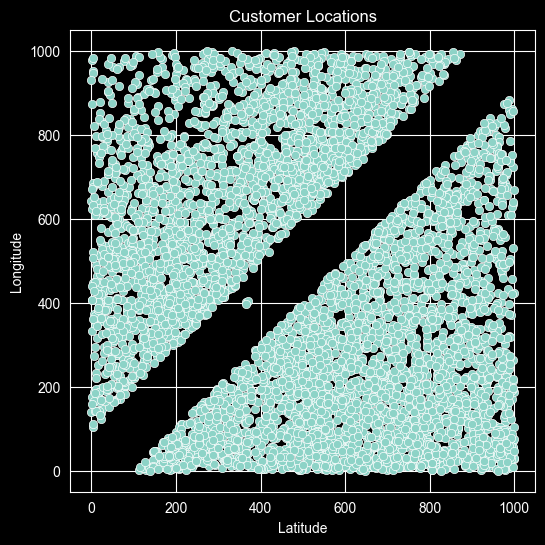

In [12]:
plt.figure(figsize=(6, 6))
sns.scatterplot(data=cust_data_clean, x='Longitude', y='Latitude')
plt.title('Customer Locations')
plt.xlabel('Latitude')
plt.ylabel('Longitude')
plt.show()

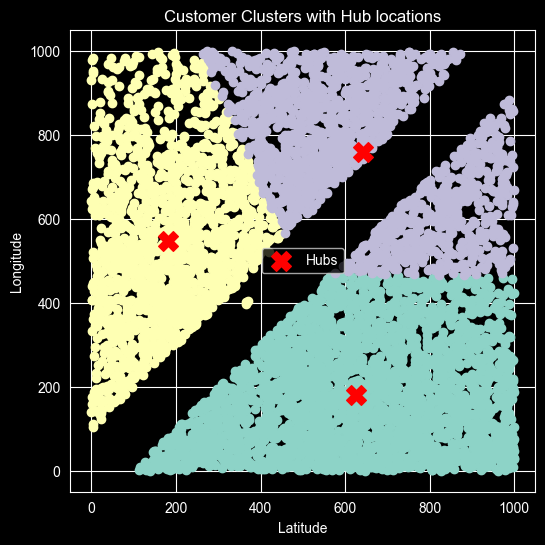

In [16]:
X = cust_data_clean[['Longitude', 'Latitude']]

kmeans = KMeans(n_clusters=3, random_state=42)
cust_data_clean['cluster'] = kmeans.fit_predict(X)

centroids = pd.DataFrame(kmeans.cluster_centers_, columns=['latitude', 'longitude'])

plt.figure(figsize=(6, 6))

for cluster in cust_data_clean['cluster'].unique():
    subset = cust_data_clean[cust_data_clean['cluster'] == cluster]
    plt.scatter(subset['Longitude'], subset['Latitude'])

plt.title("Customer Clusters with Hub locations")
plt.scatter(centroids['latitude'], centroids['longitude'], marker='X', c='red', s=200, label='Hubs')
plt.xlabel('Latitude')
plt.ylabel('Longitude')
plt.legend()
plt.show()

This visualization shows customer locations grouped into clusters. Each point is colored according to its cluster label. This visualization helps us see how customers are geographically distributed into clusters. The large X markers represent hubs, which indicate the central of each cluster region.

## Evaluation

## Deployment